In [1]:
import joblib
import pandas as pd
import shap

In [2]:
model = joblib.load(
    "../models/fraudguard_xgb.joblib"
)

print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>


In [3]:
df = pd.read_csv(
    "../data/raw/creditcard.csv"
)

df = df.drop_duplicates().copy()

X = df.drop(columns=["Class"])
y = df["Class"]

In [4]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (283726, 30)
Target: (283726,)


In [5]:
fraud_rows = df[
    df["Class"] == 1
]

print(
    "Number of fraud transactions:",
    len(fraud_rows)
)

Number of fraud transactions: 473


In [6]:
fraud_sample = (
    fraud_rows
    .drop(columns=["Class"])
    .iloc[[0]]
)

In [7]:
print(fraud_sample.shape)

(1, 30)


In [8]:
fraud_probability = model.predict_proba(
    fraud_sample
)[0, 1]

print(
    "Fraud Probability:",
    fraud_probability
)

Fraud Probability: 0.98856723


In [9]:
prediction = int(
    fraud_probability >= 0.40
)

print(
    "Prediction:",
    prediction
)

Prediction: 1


In [10]:
fraud_sample = (
    fraud_rows
    .drop(columns=["Class"])
    .iloc[[1]]
)

In [11]:
fraud_probability = model.predict_proba(
    fraud_sample
)[0, 1]

print(
    "Fraud Probability:",
    fraud_probability
)

Fraud Probability: 0.7876836


In [12]:
prediction = int(
    fraud_probability >= 0.40
)

print(
    "Prediction:",
    prediction
)

Prediction: 1


In [13]:
explainer = shap.TreeExplainer(model)

In [14]:
shap_values = explainer(fraud_sample)

In [16]:
print(shap_values.shape)

(1, 30)


In [17]:
print(
    "Base value:",
    shap_values.base_values[0]
)

Base value: -6.3896513


In [18]:
shap_table = pd.DataFrame({
    "Feature": fraud_sample.columns,
    "Feature_Value": fraud_sample.iloc[0].values,
    "SHAP_Value": shap_values.values[0]
})

In [19]:
shap_table

,Feature,Feature_Value,SHAP_Value
0,Time,472.000000,0.354822
1,V1,-3.043541,-0.064389
2,V2,-3.157307,0.040417
3,V3,1.088463,0.650984
4,V4,2.288644,1.551462
5,V5,1.359805,0.280723
6,V6,-1.064823,0.130981
7,V7,0.325574,0.020654
8,V8,-0.067794,0.335024
9,V9,-0.270953,0.063762


In [20]:
shap_table["Absolute_SHAP"] = (
    shap_table["SHAP_Value"].abs()
)

In [21]:
top_features = (
    shap_table
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .head(10)
)

In [22]:
top_features

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
4,V4,2.288644,1.551462,1.551462
14,V14,-1.692029,1.034282,1.034282
29,Amount,529.000000,0.708129,0.708129
3,V3,1.088463,0.650984,0.650984
28,V28,0.035764,0.583362,0.583362
17,V17,0.599717,0.487943,0.487943
26,V26,-0.145362,0.485430,0.485430
23,V23,1.375966,0.442956,0.442956
21,V21,0.661696,0.414273,0.414273
0,Time,472.000000,0.354822,0.354822


In [23]:
fraud_increasing = (
    shap_table[
        shap_table["SHAP_Value"] > 0
    ]
    .sort_values(
        "SHAP_Value",
        ascending=False
    )
    .head(5)
)

In [24]:
fraud_decreasing = (
    shap_table[
        shap_table["SHAP_Value"] < 0
    ]
    .sort_values(
        "SHAP_Value",
        ascending=True
    )
    .head(5)
)

In [25]:
fraud_increasing

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
4,V4,2.288644,1.551462,1.551462
14,V14,-1.692029,1.034282,1.034282
29,Amount,529.000000,0.708129,0.708129
3,V3,1.088463,0.650984,0.650984
28,V28,0.035764,0.583362,0.583362


In [26]:
fraud_decreasing

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
11,V11,-0.414575,-0.203969,0.203969
13,V13,0.676502,-0.164128,0.164128
10,V10,-0.838587,-0.162194,0.162194
16,V16,0.666780,-0.144892,0.144892
1,V1,-3.043541,-0.064389,0.064389


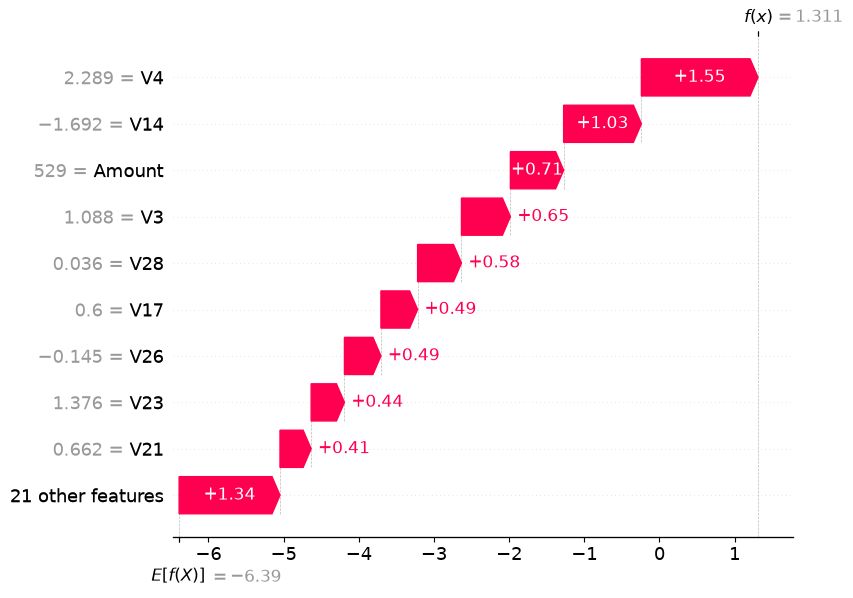

In [27]:
shap.plots.waterfall(
    shap_values[0],
    max_display=10
)

In [28]:
legitimate_rows = df[
    df["Class"] == 0
]

In [29]:
legitimate_sample = (
    legitimate_rows
    .drop(columns=["Class"])
    .iloc[[0]]
)

In [30]:
legitimate_probability = (
    model.predict_proba(
        legitimate_sample
    )[0, 1]
)

print(
    "Fraud Probability:",
    legitimate_probability
)

print(
    "Prediction:",
    int(
        legitimate_probability >= 0.40
    )
)

Fraud Probability: 9.684223e-05
Prediction: 0


In [31]:
legitimate_shap = explainer(
    legitimate_sample
)

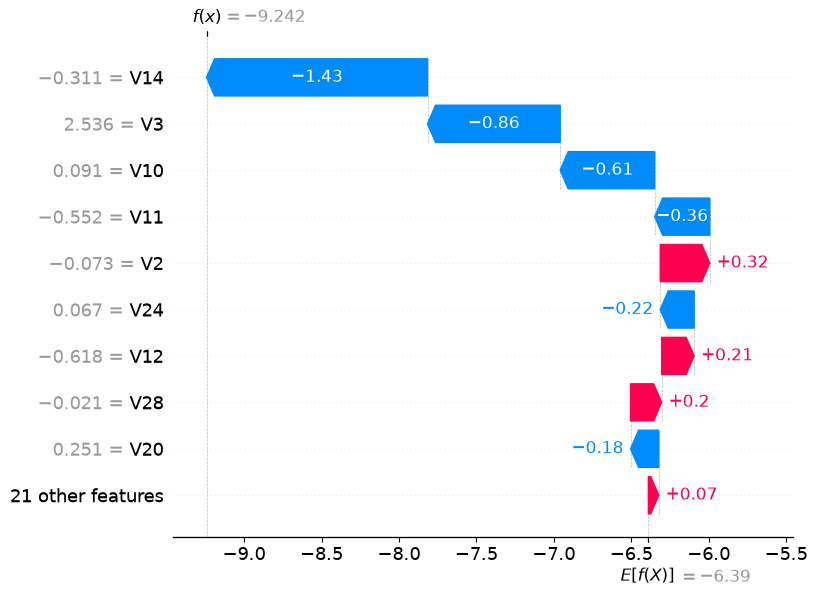

In [32]:
shap.plots.waterfall(
    legitimate_shap[0],
    max_display=10
)

In [33]:
X_sample = X.sample(
    n=5000,
    random_state=42
)

print(X_sample.shape)

(5000, 30)


In [34]:
global_shap_values = explainer(
    X_sample
)

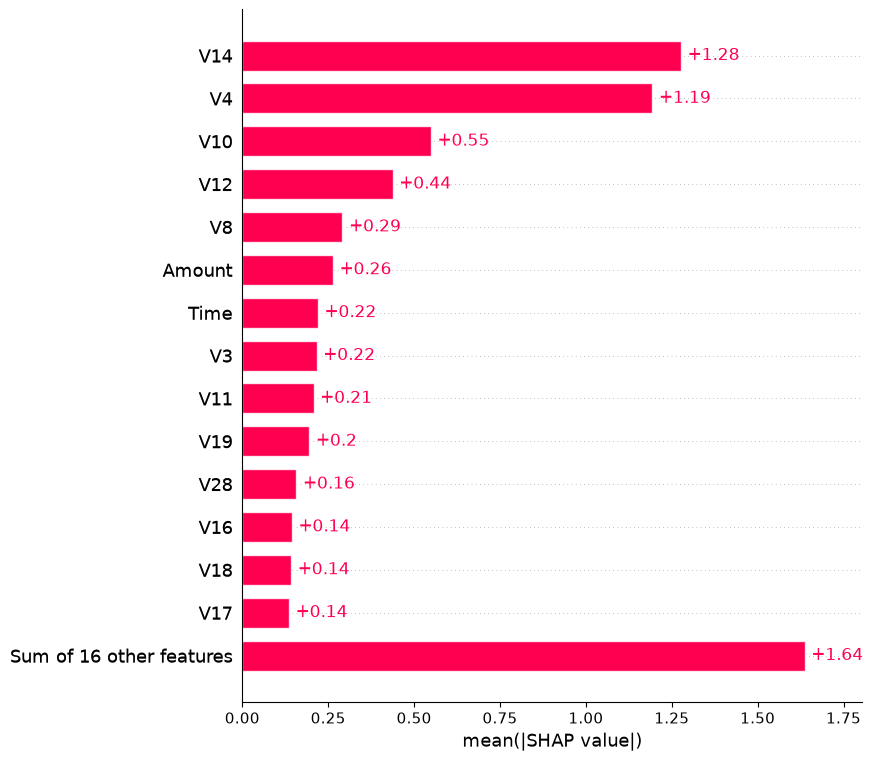

In [35]:
shap.plots.bar(
    global_shap_values,
    max_display=15
)

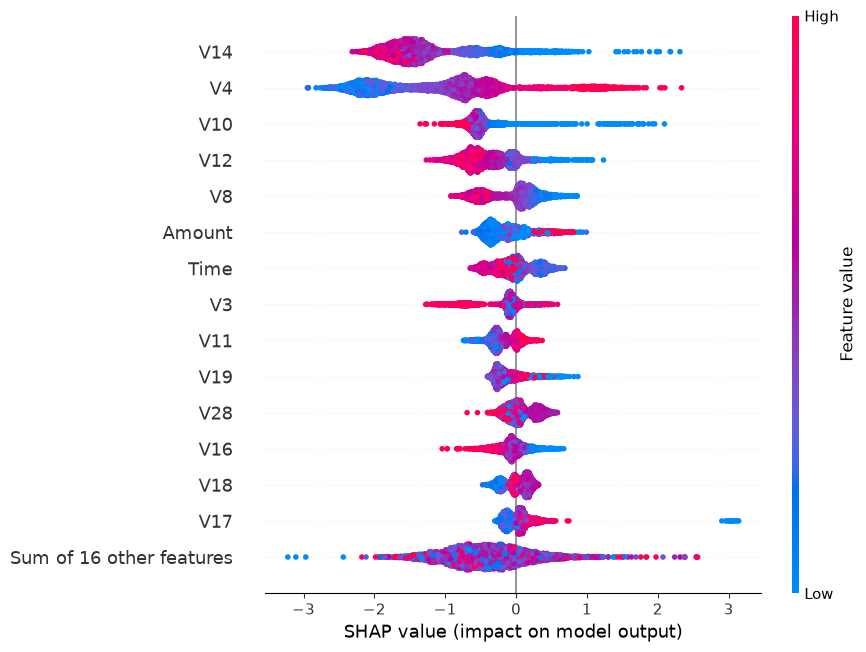

In [36]:
shap.plots.beeswarm(
    global_shap_values,
    max_display=15
)

In [37]:
import numpy as np

In [38]:
global_importance = pd.DataFrame({
    "Feature": X_sample.columns,

    "Mean_Absolute_SHAP": (
        np.abs(
            global_shap_values.values
        ).mean(axis=0)
    )
})

In [39]:
global_importance = (
    global_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

In [40]:
global_importance.head(10)

,Feature,Mean_Absolute_SHAP
0,V14,1.276968
1,V4,1.193474
2,V10,0.548862
3,V12,0.437563
4,V8,0.291442
5,Amount,0.263783
6,Time,0.219788
7,V3,0.216283
8,V11,0.207313
9,V19,0.195021
